In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm



In [2]:
df = pd.read_csv("cleaned_int_rate.csv", low_memory=False)


target = "int_rate"

In [5]:
x = df.drop(columns=[target])
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**.5:.4f}")

x_train_const = sm.add_constant(x_train.astype(float))
ols_full = sm.OLS(y_train.astype(float), x_train_const).fit()
print(ols_full.summary())

R²:   0.9386
MAE:  0.7314
RMSE: 1.1957
                            OLS Regression Results                            
Dep. Variable:               int_rate   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                 6.031e+05
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:31:26   Log-Likelihood:            -2.5727e+06
No. Observations:             1805112   AIC:                         5.145e+06
Df Residuals:                 1805045   BIC:                         5.146e+06
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [6]:

drop_cols = [c for c in x_train.columns if c.startswith("sub_grade")]

x_train_v2 = x_train.drop(columns=drop_cols)
x_test_v2 = x_test.drop(columns=drop_cols)

lr2 = LinearRegression()
lr2.fit(x_train_v2, y_train)
y_pred_v2 = lr2.predict(x_test_v2)

print(f"R²:   {r2_score(y_test, y_pred_v2):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_v2):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_v2)**.5:.4f}")

x_train_v2_const = sm.add_constant(x_train_v2.astype(float))
ols_borrower = sm.OLS(y_train.astype(float), x_train_v2_const).fit()
print(ols_borrower.summary())

R²:   0.4431
MAE:  2.7527
RMSE: 3.6001
                            OLS Regression Results                            
Dep. Variable:               int_rate   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                 4.514e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:31:56   Log-Likelihood:            -4.8740e+06
No. Observations:             1805112   AIC:                         9.748e+06
Df Residuals:                 1805079   BIC:                         9.749e+06
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

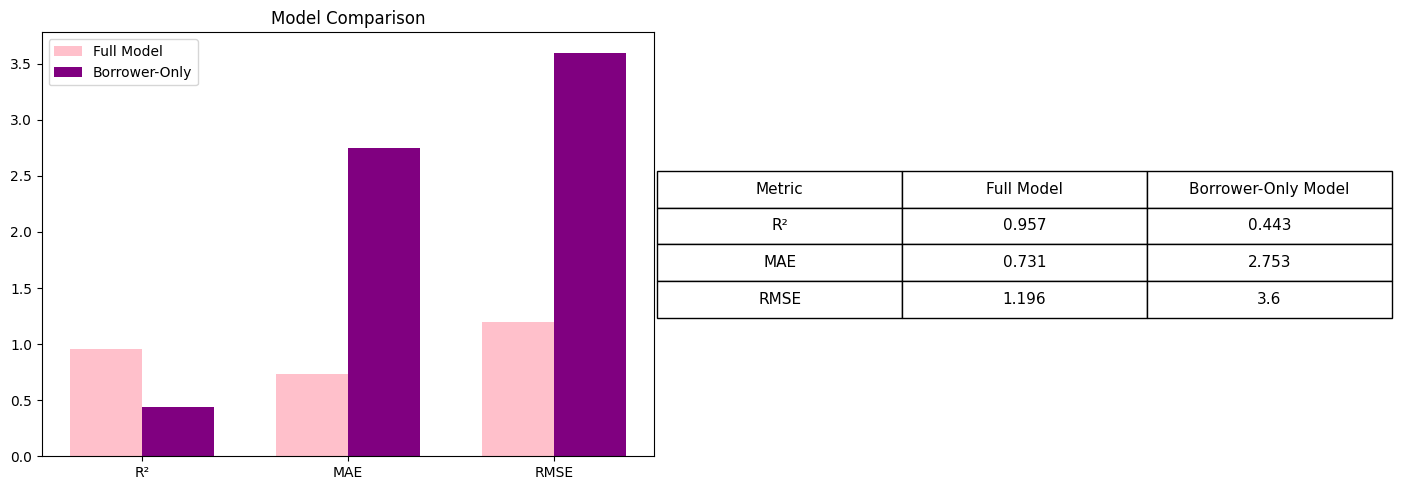

In [ ]:
metrics = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Full Model": [0.957, 0.731, 1.196],
    "Borrower-Only Model": [0.443, 2.753, 3.600]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = range(len(metrics))
width = 0.35
axes[0].bar([i - width/2 for i in x], metrics["Full Model"], width, label="Full Model", color="pink")
axes[0].bar([i + width/2 for i in x], metrics["Borrower-Only Model"], width, label="Borrower-Only", color="purple")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics["Metric"])
axes[0].set_title("Model Comparison")
axes[0].legend()

# Table
axes[1].axis("off")
table = axes[1].table(
    cellText=metrics.values,
    colLabels=metrics.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

plt.tight_layout()
plt.show()
plt.close()

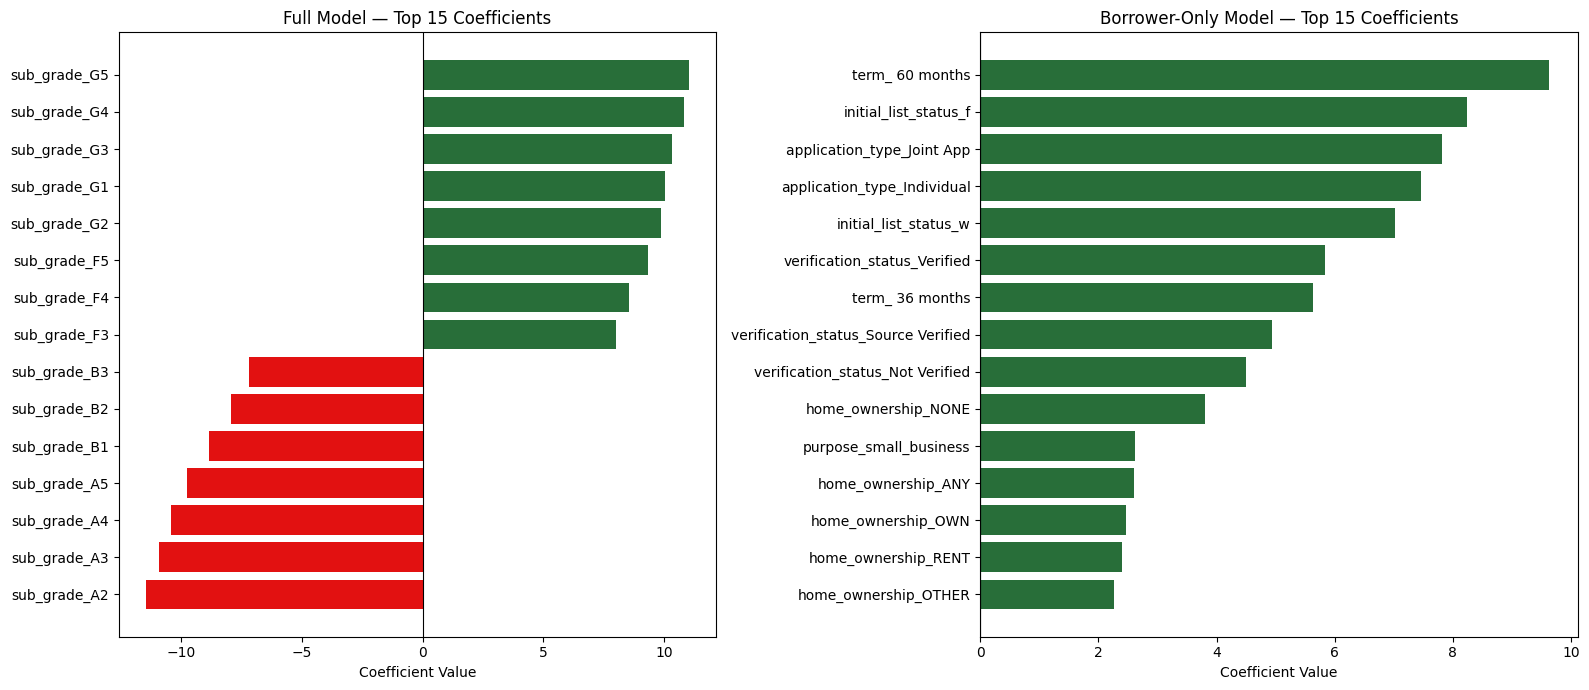

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


full_coef = pd.DataFrame({
    "Variable": ols_full.params.index,
    "Coefficient": ols_full.params.values
}).sort_values("Coefficient", key=abs, ascending=False).iloc[1:16]  # skip const

full_coef_sorted = full_coef.sort_values("Coefficient")
colors_full = ["#286E39" if v > 0 else "#E21111" for v in full_coef_sorted["Coefficient"]]
axes[0].barh(full_coef_sorted["Variable"], full_coef_sorted["Coefficient"], color=colors_full)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Full Model — Top 15 Coefficients")
axes[0].set_xlabel("Coefficient Value")

borrower_coef = pd.DataFrame({
    "Variable": ols_borrower.params.index,
    "Coefficient": ols_borrower.params.values
}).sort_values("Coefficient", key=abs, ascending=False).iloc[1:16]

borrower_coef_sorted = borrower_coef.sort_values("Coefficient")
colors_borrower = ["#286E39" if v > 0 else "#E21111" for v in borrower_coef_sorted["Coefficient"]]
axes[1].barh(borrower_coef_sorted["Variable"], borrower_coef_sorted["Coefficient"], color=colors_borrower)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Borrower-Only Model — Top 15 Coefficients")
axes[1].set_xlabel("Coefficient Value")

plt.tight_layout()

plt.show()
plt.close()

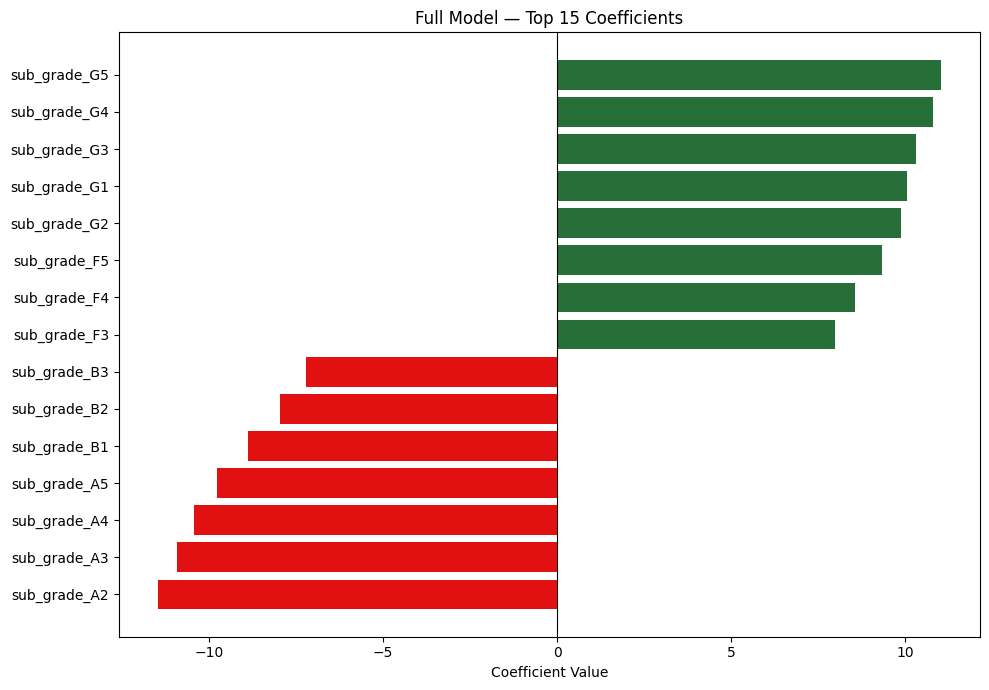

In [ ]:

full_coef = pd.DataFrame({
    "Variable": ols_full.params.index,
    "Coefficient": ols_full.params.values
}).sort_values("Coefficient", key=abs, ascending=False).iloc[1:16]

full_coef_sorted = full_coef.sort_values("Coefficient")
colors_full = ["#286E39" if v > 0 else "#E21111" for v in full_coef_sorted["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(full_coef_sorted["Variable"], full_coef_sorted["Coefficient"], color=colors_full)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Full Model — Top 15 Coefficients")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()

plt.show()
plt.close()

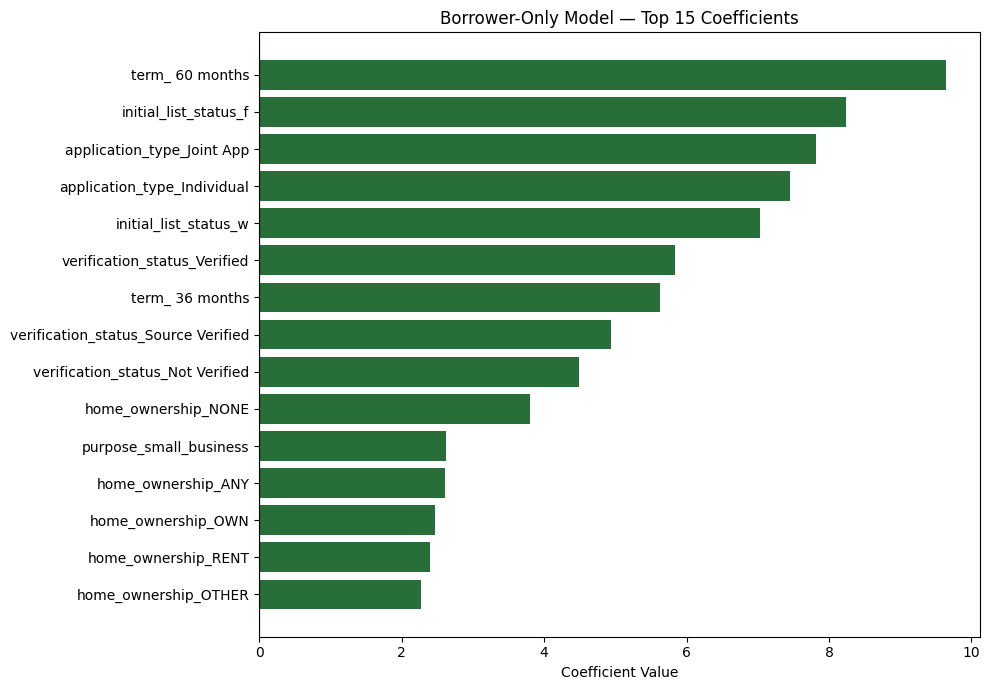

In [ ]:

borrower_coef = pd.DataFrame({
    "Variable": ols_borrower.params.index,
    "Coefficient": ols_borrower.params.values
}).sort_values("Coefficient", key=abs, ascending=False).iloc[1:16]

borrower_coef_sorted = borrower_coef.sort_values("Coefficient")
colors_borrower = ["#286E39" if v > 0 else "#E21111" for v in borrower_coef_sorted["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(borrower_coef_sorted["Variable"], borrower_coef_sorted["Coefficient"], color=colors_borrower)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Borrower-Only Model — Top 15 Coefficients")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("borrower_model_coefficients.png")
plt.show()
plt.close()